In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

In [2]:
drive = pd.read_csv('dataset.csv').sample(500000, random_state= 101)
drive.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 500000 entries, 879155 to 46460
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   DriverId    500000 non-null  int64  
 1   EventName   500000 non-null  object 
 2   Latitude    500000 non-null  float64
 3   Longitude   500000 non-null  float64
 4   Speed km/h  500000 non-null  float64
 5   ts          500000 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 26.7+ MB


In [3]:
drive.describe()

,DriverId,Latitude,Longitude,Speed km/h
count,500000.000000,500000.000000,500000.000000,500000.000000
mean,43.603432,34.150554,-118.170108,63.178408
std,26.447291,0.449096,0.164704,39.023530
min,0.000000,31.553245,-118.662188,0.000000
25%,19.000000,33.940708,-118.284584,30.000000
50%,45.000000,34.104864,-118.209604,65.000000
75%,65.000000,34.428364,-118.085719,96.000000
max,88.000000,35.248755,-117.442857,178.000000


In [4]:
drive = drive.drop_duplicates()
drive = drive.drop(drive[drive['Speed km/h'] < 5].index)

In [5]:
drive.sample(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts
563357,52,Distance Event,33.272269,-118.267533,69.0,2017-11-05 14:36:53.140
310854,31,Distance Event,34.783969,-118.080632,37.0,2017-11-01 11:50:04.650
225350,19,Distance Event,33.909214,-118.264505,72.0,2017-11-04 21:12:11.510
172899,15,Distance Event,34.835086,-118.108535,33.0,2017-11-14 09:57:09.370
778513,77,Distance Event,34.846475,-117.961296,92.0,2017-11-10 19:26:21.680
125122,10,Timed Event,34.074869,-118.266477,15.0,2017-11-08 17:32:51.010
113554,8,Distance Event,34.012578,-118.294071,108.0,2017-11-11 11:24:47.140
280302,25,Distance Event,33.904647,-118.149042,110.0,2017-11-17 12:47:58.660
622180,59,Harsh Acceleration,34.927544,-117.939055,74.0,2017-11-15 07:15:12.800
376660,39,Distance Event,34.145541,-118.281574,121.0,2017-11-11 06:10:10.280


In [6]:
drive.EventName.value_counts()

Distance Event                       375381
Timed Event                           47223
Harsh Acceleration                     8942
System Event                           3256
Harsh Braking                          3207
Reached max speed                      3016
Out of max speed                       1394
Network Event                          1341
Harsh Turn (motion based)              1271
Harsh Braking (motion based)            729
Engine started                          662
Engine turned off                       516
Harsh Acceleration (motion based)       452
Harsh Turn Right (motion based)         444
Harsh Turn Left (motion based)          434
Name: EventName, dtype: int64

In [7]:
drp = ['System Event', 'Network Event','Engine turned off', 'Engine started','Distance Event']
rest = list(set(drive.EventName.unique()).difference(set(drp)))
make = drive[drive.EventName.isin(rest)]

In [8]:
make = make.replace({'EventName': {'Harsh Acceleration (motion based)':'Harsh Acceleration',
                       'Harsh Braking (motion based)':'Harsh Braking',
                        'Harsh Acceleration (motion based)':'Harsh Acceleration',
                        'Harsh Turn Left (motion based)':'Harsh Turn',
                        'Harsh Turn Right (motion based)':'Harsh Turn',
                        'Harsh Turn (motion based)':'Harsh Turn',
                        'Reached max speed': 'Beyond max speed',
                        'Out of max speed':'Beyond max speed'}})

make.EventName.value_counts()

Timed Event           47223
Harsh Acceleration     9394
Beyond max speed       4410
Harsh Braking          3936
Harsh Turn             2149
Name: EventName, dtype: int64

In [9]:
# Days of the Week
import datetime
make.ts = pd.to_datetime(make.ts) #.strftime('%d/%m/%Y %H:%M')
make['Days'] =  [t.date().strftime('%A') for t in make.ts] #ake.ts.date().apply(lambda date: datetime.date(date).strftime('%A'))
# Visibility
make['visiblity'] = ['Light'if i.time().hour < 20 and i.time().hour > 6 else 'Dark'for i in make.ts]
# Aggressive Driving
crz = ['Harsh Acceleration', 'Harsh Braking', 'Harsh Turn', 'Beyond max speed']
make['agg_drv'] = [1 if i in crz else 0 for i in make.EventName]
# Overspeed
# Speed threshold is set at 80
make['overspeed'] = [1 if make.iloc[i]['Speed km/h'] > 80 else 1 if make.iloc[i]['EventName']=='Harsh Turn' 
                        and make.iloc[i]['Speed km/h'] > 40 else 0 for i in range(len(make))]
# Fatigue Driving
make['fatigue'] = rd.choices(['Yes', 'No'], weights=[10,30], k=len(make))


# Possible collision distance
# This is a subraction of stopping distance from car distance:
# Taking reaction time to be 0.75s for normal and 1.5 for fatigued, road coef to asphalt,
# car distance to 3s
make['col_dist'] = [round((make.iloc[i]['Speed km/h'] *3)/3.6 - ((make.iloc[i]['Speed km/h'] * 1.5)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2)  if make.iloc[i]['fatigue']=='Yes' 
else round((make.iloc[i]['Speed km/h']*3)/3.6 - ((make.iloc[i]['Speed km/h'] * 0.75)/3.6 + make.iloc[i]['Speed km/h']**2/(250*0.8)), 2) for i in range(len(make))]

In [10]:
make.head(10)

,DriverId,EventName,Latitude,Longitude,Speed km/h,ts,Days,visiblity,agg_drv,overspeed,fatigue,col_dist
879155,87,Timed Event,34.124660,-118.130796,23.0,2017-11-16 08:49:28.520,Thursday,Light,0,0,No,11.73
533839,51,Harsh Acceleration,33.928296,-118.083349,49.0,2017-11-01 19:18:46.780,Wednesday,Light,1,0,No,18.62
6535,0,Timed Event,34.067303,-118.261615,64.0,2017-11-07 14:45:03.060,Tuesday,Light,0,0,No,19.52
749935,76,Timed Event,34.136694,-118.238141,18.0,2017-11-06 09:22:40.670,Monday,Light,0,0,No,9.63
176417,15,Timed Event,34.792958,-118.051337,51.0,2017-11-16 19:39:04.090,Thursday,Light,0,0,No,18.87
657730,63,Timed Event,34.002073,-118.295474,67.0,2017-11-06 07:52:10.020,Monday,Light,0,0,Yes,5.47
738843,75,Harsh Acceleration,33.970864,-118.311289,70.0,2017-11-13 18:37:23.750,Monday,Light,1,0,No,19.25
508104,49,Timed Event,34.039634,-118.335961,16.0,2017-11-08 10:48:12.930,Wednesday,Light,0,0,No,8.72
598785,56,Timed Event,34.134110,-118.222145,73.0,2017-11-02 17:40:49.470,Thursday,Light,0,0,Yes,3.77
728362,73,Harsh Braking,34.554256,-117.736918,42.0,2017-11-17 06:53:37.570,Friday,Dark,1,0,No,17.43


In [11]:
make.DriverId.unique(), make.DriverId.nunique()

(array([87, 51,  0, 76, 15, 63, 75, 49, 56, 73, 65, 58, 18, 81, 33, 46, 41,
        47, 39, 52, 85, 11, 10,  8, 12, 24, 20, 62,  5, 25, 48, 45, 31, 27,
         1, 44, 77, 70, 61, 82, 22, 40,  7, 14, 60, 59, 78, 68, 54, 84, 23,
        36, 88, 72, 16,  2, 74, 57,  9, 17, 28, 30, 67,  4, 35, 13, 69, 37,
        55, 42, 21, 86,  6, 26, 53, 80, 32, 79, 19,  3, 50, 29, 38, 83, 66,
        43, 71]),
 87)

In [12]:
make = make.drop(['DriverId', 'Longitude', 'Latitude', 'ts'], axis=1)
make.corr() 

,Speed km/h,agg_drv,overspeed,col_dist
Speed km/h,1.000000,0.202067,0.805663,-0.233577
agg_drv,0.202067,1.000000,0.071198,0.080715
overspeed,0.805663,0.071198,1.000000,-0.387004
col_dist,-0.233577,0.080715,-0.387004,1.000000


In [13]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10

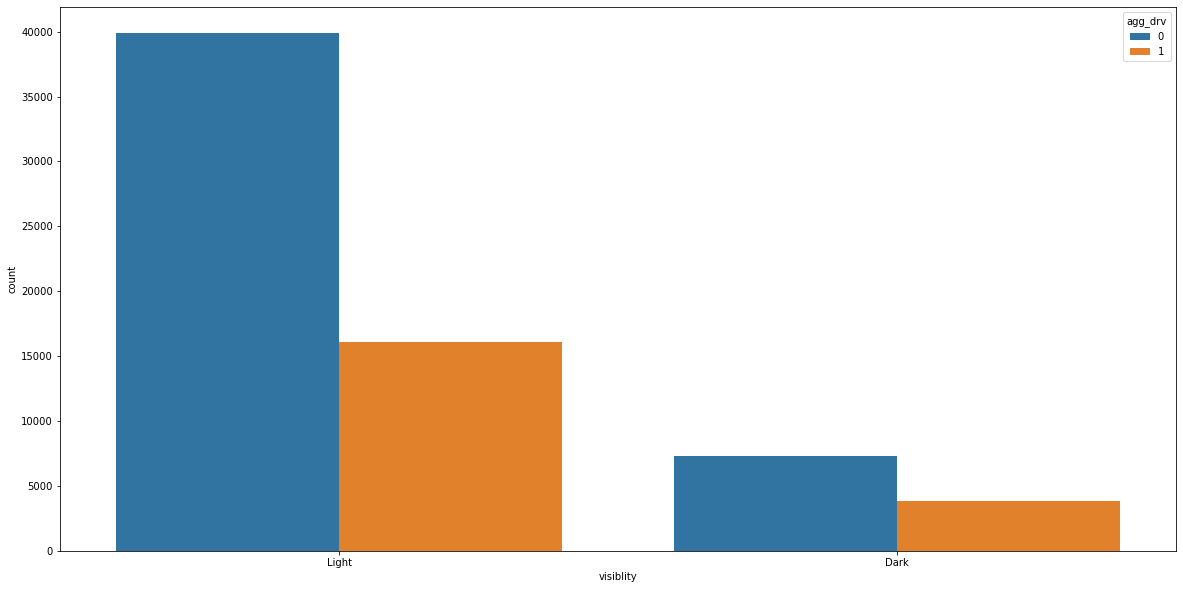

In [14]:
sns.countplot(x= 'visiblity', data = make, hue ='agg_drv')

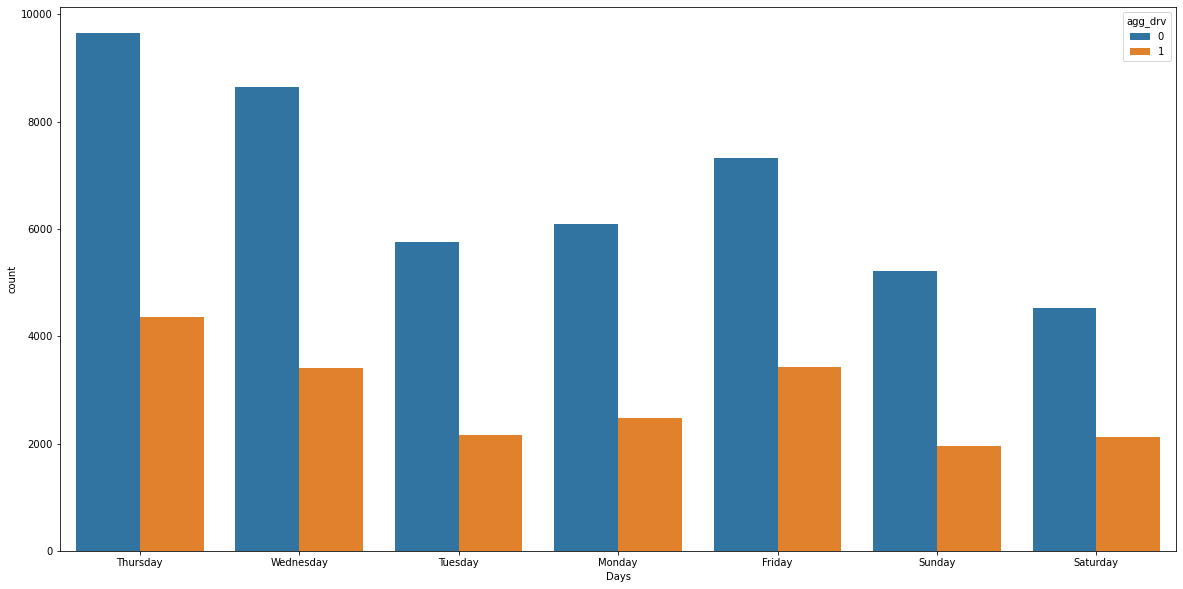

In [15]:
sns.countplot(x= 'Days', data = make, hue ='agg_drv')

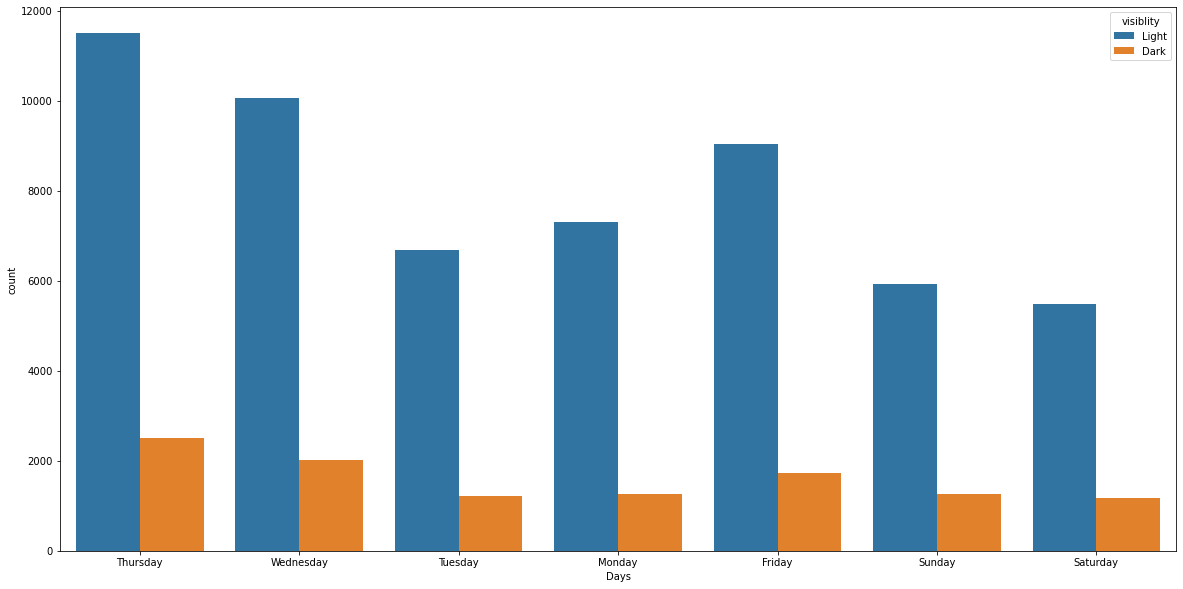

In [16]:
sns.countplot(x= 'Days', data = make, hue ='visiblity')

In [17]:
make.fatigue.value_counts()

No     50404
Yes    16708
Name: fatigue, dtype: int64

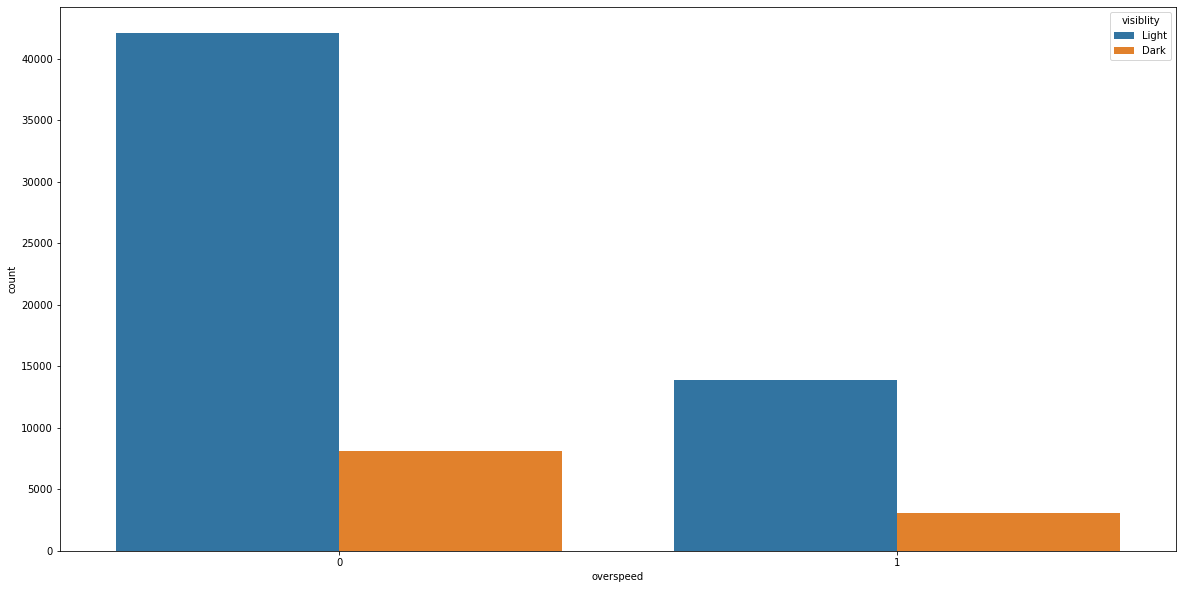

In [18]:
sns.countplot(x= 'overspeed', data = make, hue ='visiblity')

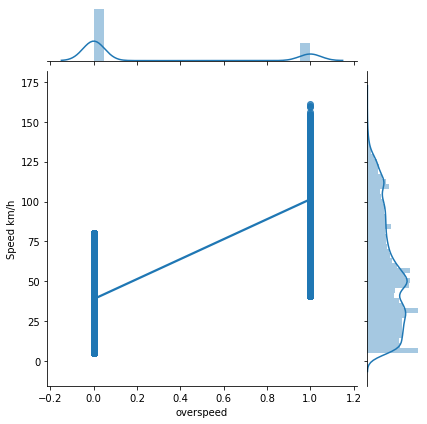

In [19]:
sns.jointplot(x = "overspeed", y = "Speed km/h", data= make, kind='reg')

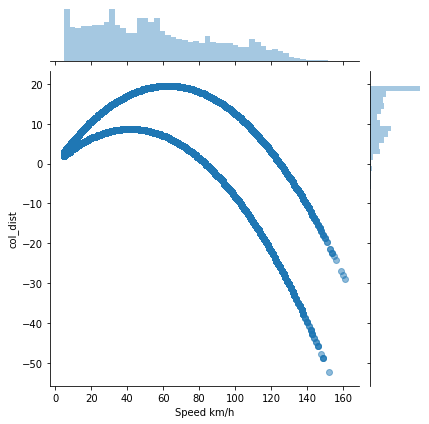

In [20]:
sns.jointplot(y= "col_dist", x = "Speed km/h", data= make, alpha =0.5)

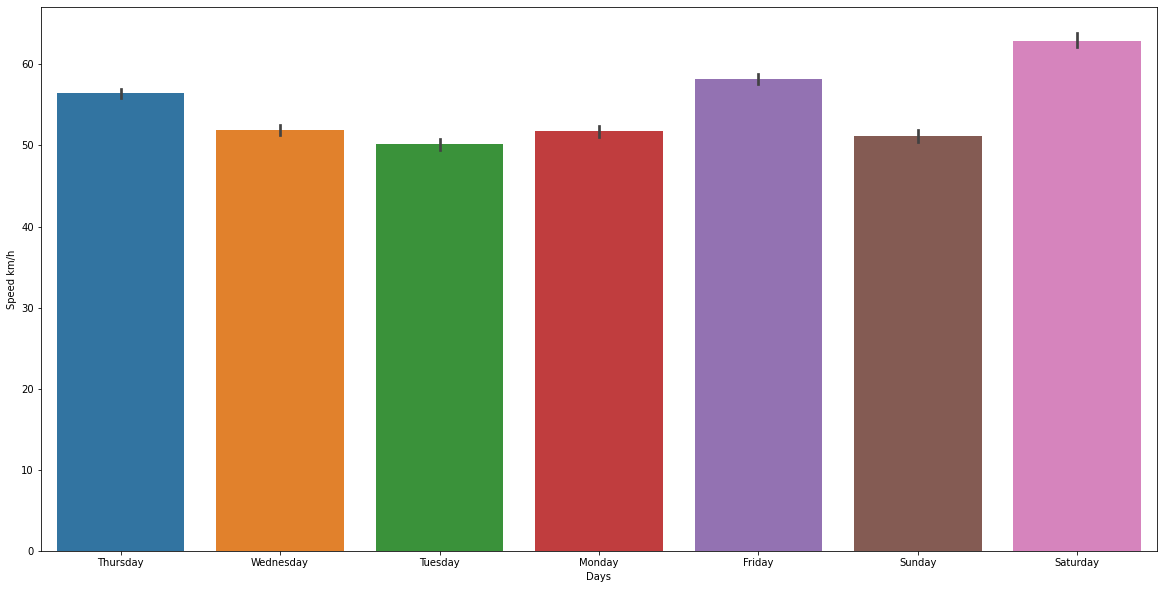

In [21]:
sns.barplot(x = 'Days', y='Speed km/h', data =make)

/home/jubriel/anaconda3/lib/python3.8/site-packages/seaborn/distributions.py:369: UserWarning: Default bandwidth for data is 0; skipping density estimation.
  warnings.warn(msg, UserWarning)


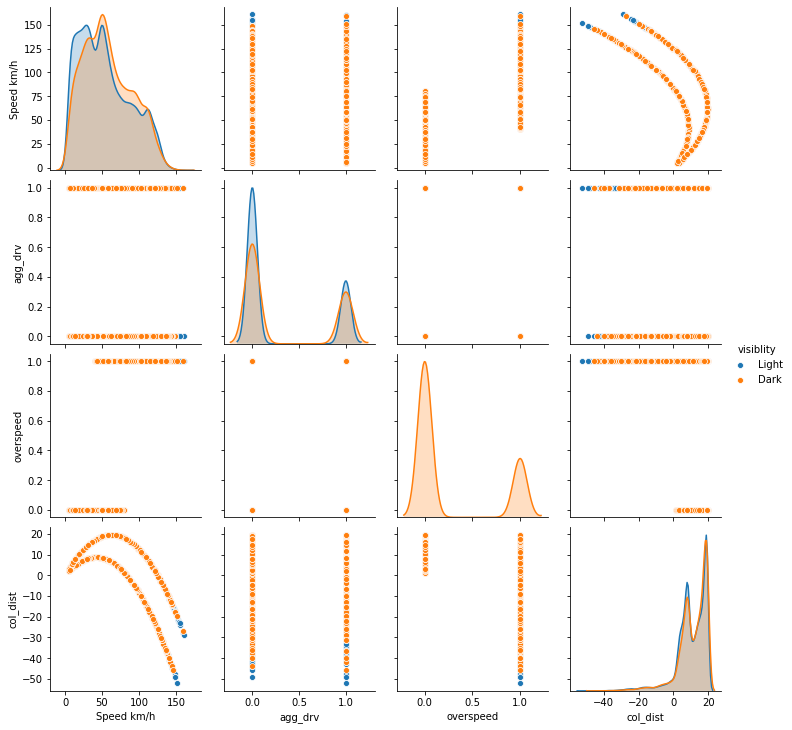

In [22]:
sns.pairplot(make, hue='visiblity')

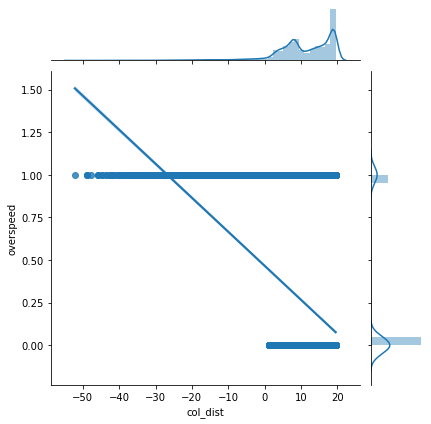

In [23]:
sns.jointplot(x = "col_dist", y = "overspeed", data= make, kind='reg')

In [24]:
maked = make.copy()

In [25]:
make.EventName.value_counts()

Timed Event           47223
Harsh Acceleration     9394
Beyond max speed       4410
Harsh Braking          3936
Harsh Turn             2149
Name: EventName, dtype: int64

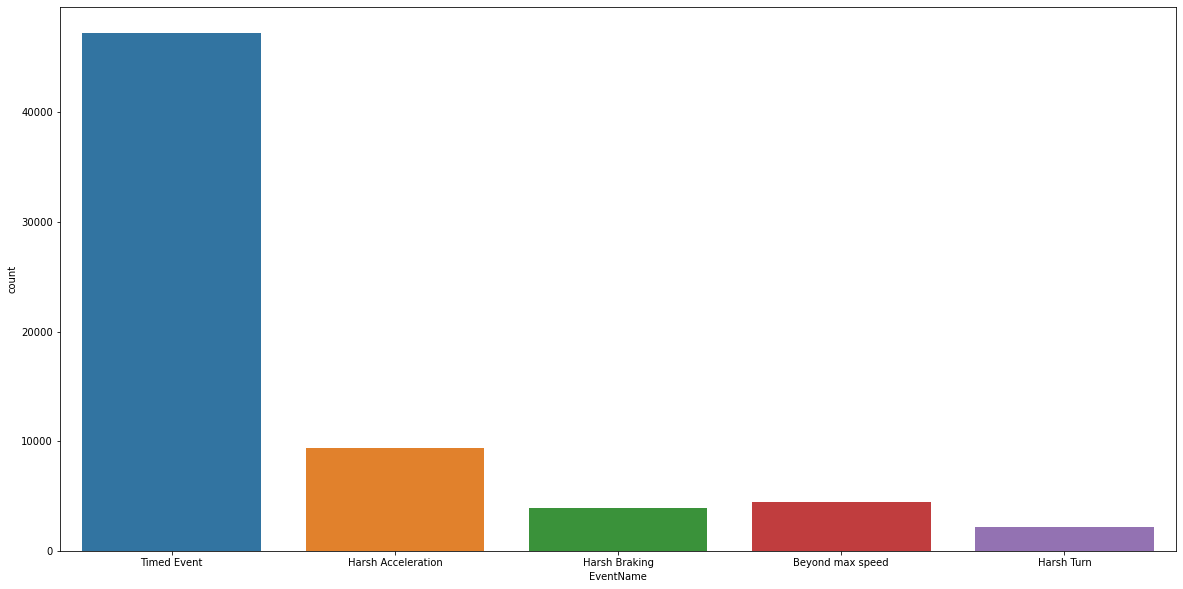

In [26]:
sns.countplot(data = make, x='EventName')

In [27]:
make.sample(20)

,EventName,Speed km/h,Days,visiblity,agg_drv,overspeed,fatigue,col_dist
736881,Timed Event,15.0,Saturday,Light,0,0,Yes,5.12
65850,Timed Event,58.0,Wednesday,Light,0,0,No,19.43
823182,Timed Event,30.0,Wednesday,Light,0,0,No,14.25
124463,Harsh Braking,53.0,Monday,Light,1,0,No,19.08
767542,Timed Event,24.0,Friday,Light,0,0,No,12.12
561621,Timed Event,26.0,Thursday,Dark,0,0,Yes,7.45
687700,Beyond max speed,112.0,Wednesday,Light,1,1,No,7.28
753202,Timed Event,105.0,Thursday,Dark,0,1,No,10.50
533692,Timed Event,89.0,Wednesday,Light,0,1,No,16.02
239047,Harsh Turn,35.0,Wednesday,Light,1,0,No,15.75


In [28]:
# make['Decision'] = ['Guilty' if (make.iloc[i]['overspeed']==1 and make.iloc[i]['fatigue']=='Yes') or 
#                             (make.iloc[i]['agg_drv']=='1' and make.iloc[i]['fatigue']=='Yes') or 
#                             (make.iloc[i]['col_dist'] < 1 and make.iloc[i]['fatigue']=='Yes') 
#                             else 'Guilty' if (make.iloc[i]['overspeed']==1 and make.iloc[i]['agg_drv']=='Yes') or
#                             (make.iloc[i]['col_dist'] < 1 and make.iloc[i]['overspeed']==1)
#                             else 'Innocent' for i in range(len(make))]


In [29]:
mak = make.copy()
mak.visiblity = make.visiblity.map({'Light':0, 'Dark':1})
mak.fatigue = make.fatigue.map({'Yes':1,'No':0})
mak['col_distd'] = [1 if i < 1 else 0 for i in make.col_dist]
# make['Decision'] = [round(0.5*make.iloc[i]['Speed km/h'] - 0.4*make.iloc[i]['visiblity'] + 0.5*make.iloc[i]['agg_drv']
#                     + 0.5*make.iloc[i]['fatigue'] + 0.6*make.iloc[i]['overspeed'] - 0.727*make.iloc[i]['col_dist'],2)/100
#                     for i in range(len(make))]
mak['Decision'] = [round((0.4 * mak.iloc[i]['Speed km/h'] + 0.01 * mak.iloc[i]['visiblity'] + 0.1*mak.iloc[i]['agg_drv']
                    + 0.4*mak.iloc[i]['fatigue'] + 0.3*mak.iloc[i]['overspeed'] - 0.08*mak.iloc[i]['col_distd'])/100,2)
                    for i in range(len(mak))]


In [30]:
mak.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67112 entries, 879155 to 557928
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EventName   67112 non-null  object 
 1   Speed km/h  67112 non-null  float64
 2   Days        67112 non-null  object 
 3   visiblity   67112 non-null  int64  
 4   agg_drv     67112 non-null  int64  
 5   overspeed   67112 non-null  int64  
 6   fatigue     67112 non-null  int64  
 7   col_dist    67112 non-null  float64
 8   col_distd   67112 non-null  int64  
 9   Decision    67112 non-null  float64
dtypes: float64(3), int64(5), object(2)
memory usage: 5.6+ MB


In [31]:
mak.corr()['Decision']
# make.corr()

Speed km/h    0.999699
visiblity     0.042230
agg_drv       0.204547
overspeed     0.808427
fatigue       0.011277
col_dist     -0.240151
col_distd     0.483592
Decision      1.000000
Name: Decision, dtype: float64

In [32]:
mak.Decision.unique()

array([0.09, 0.2 , 0.26, 0.07, 0.27, 0.28, 0.06, 0.3 , 0.17, 0.08, 0.12,
       0.47, 0.51, 0.24, 0.45, 0.46, 0.13, 0.34, 0.04, 0.14, 0.35, 0.39,
       0.33, 0.43, 0.36, 0.1 , 0.41, 0.11, 0.23, 0.42, 0.16, 0.03, 0.5 ,
       0.19, 0.29, 0.21, 0.22, 0.25, 0.37, 0.18, 0.05, 0.02, 0.44, 0.48,
       0.4 , 0.49, 0.38, 0.15, 0.32, 0.52, 0.54, 0.31, 0.55, 0.53, 0.58,
       0.56, 0.57, 0.59, 0.64, 0.6 , 0.63, 0.65, 0.61, 0.62])

In [33]:
make['Decision'] = [1 if i > 0.4 else 0 for i in mak.Decision]

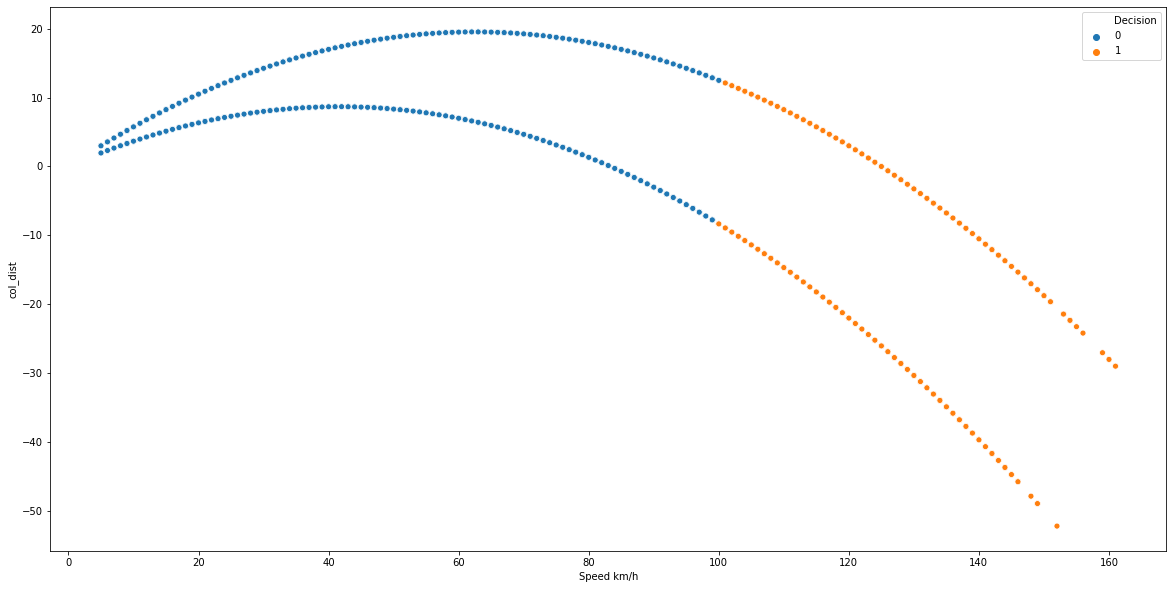

In [34]:
sns.scatterplot(y = "col_dist", x = "Speed km/h", data= make,hue="Decision")

In [35]:
make.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 67112 entries, 879155 to 557928
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   EventName   67112 non-null  object 
 1   Speed km/h  67112 non-null  float64
 2   Days        67112 non-null  object 
 3   visiblity   67112 non-null  object 
 4   agg_drv     67112 non-null  int64  
 5   overspeed   67112 non-null  int64  
 6   fatigue     67112 non-null  object 
 7   col_dist    67112 non-null  float64
 8   Decision    67112 non-null  int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 7.6+ MB


In [36]:
make.Decision.value_counts()

0    58377
1     8735
Name: Decision, dtype: int64

In [37]:
# Importing packages
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
# from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier 

In [38]:
X = make.drop('Decision', axis =1)
y = make.Decision

In [39]:
make.columns

Index(['EventName', 'Speed km/h', 'Days', 'visiblity', 'agg_drv', 'overspeed',
       'fatigue', 'col_dist', 'Decision'],
      dtype='object')

In [40]:
mak.to_csv('Work.csv', index=False)

In [41]:
# stroke = stroke.drop('id' , axis =1)
train_X,test_X, train_y, test_y = train_test_split(X,y, test_size = 0.3, random_state = 101)

import category_encoders as ce
encode = ce.TargetEncoder(cols= ['EventName', 'visiblity', 'Days','fatigue'])
train_X = encode.fit_transform(train_X,train_y)
test_X = encode.transform(test_X)

In [42]:
sc = StandardScaler()
train_X = sc.fit_transform(train_X)
test_X = sc.transform(test_X)

In [43]:
# from sklearn.cluster import DBSCAN, KMeans

# n = 2
# model = KMeans(n_clusters= n, init='k-means++', 
#                 max_iter=100, n_init=100)
# yhat = model.fit_predict(train_X)
# r = yhat.tolist()

In [44]:
# Finding the BaseLine perfomance of the various models

# prepare models
models = []

# Adding algorthms
models.append(('sgd', SGDClassifier()))
models.append(('LR', LogisticRegression()))
# models.append(('knr', KNeighborsClassifier()))
models.append(('rfr', RandomForestClassifier()))
models.append(('xg', XGBClassifier(objective ='reg:squarederror')))
# evaluate -cross validation- each model in turn
results = []
names = []
scoring =['accuracy', 'f1']
for name, model in models:
	kfold = KFold(n_splits=10)
	cv_results = cross_validate(model, train_X, train_y, cv=kfold, scoring=scoring, return_train_score=True)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results['train_accuracy'].mean(), cv_results['test_f1'].mean())
	print(msg)


sgd: 0.998082 (0.992279)
LR: 0.999908 (0.999345)
rfr: 1.000000 (1.000000)
xg: 1.000000 (1.000000)


In [45]:
wrk = pd.read_csv('Work.csv').drop(['EventName', 'Decision','col_distd'], axis=1)
wrk.columns

Index(['Speed km/h', 'Days', 'visiblity', 'agg_drv', 'overspeed', 'fatigue',
       'col_dist'],
      dtype='object')

In [46]:
import category_encoders as ce
encode = ce.BinaryEncoder(cols= ['visiblity', 'Days','fatigue'])
wrk = encode.fit_transform(wrk)

sc = StandardScaler()
wrkd = sc.fit_transform(wrk)

clust = DBSCAN(eps=3, min_samples=2).fit_predict(wrkd)
wrk['D'] = clust.labels_

NameError: name 'DBSCAN' is not defined